### 01. Mount Google Drive
This will prompt you to allow Colab to access your Google Drive files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 02. Locate and Read the Excel File
After mounting, your drive files are located under `/content/drive/MyDrive/`. Make sure the file path matches where you saved `DETask.xlsx`.

In [ ]:
import pandas as pd
import os

# Path to the file
file_path = '/content/drive/MyDrive/DETask.xlsx'

if os.path.exists(file_path):
    # Reading the specific sheet 'test_data'
    df = pd.read_excel(file_path, sheet_name='test_data')
    print("Data from sheet: test_data")
    display(df.head())
else:
Healthcare Claims Data Pipeline - Google Colab Demo
This notebook demonstrates the complete medallion architecture pipeline using Python, simulating the AWS-based solution from our architecture design.    print(f"File not found at {file_path}. Please check the folder path in your Google Drive.")

Data from sheet: test_data


,CLAIMANT_ID,CLAIM_ITEM_ID,TYPE,RECEIVED_DATE,CHARGE_AMT,ALLOWED_AMT,DIAG_CODE_1,DIAG_CODE_2,DIAG_CODE_3,DIAG_CODE_4,DIAG_CODE_5,CLAIM_CODE,Rev Code/PROCEDURE_DESCRIPTION,CLAIM_CODE_MODIFIER,CLAIM_CODE_MODIFIER_2,UNITS,OI_IN_NETWORK,SERVICE_PROVIDER,SERVICE_ADDRESS_3,SERVICE_ADDRESS_2
0,1059418,17364687,NaN,2021-09-07,300.0,300.0,Z20828,NaN,NaN,NaN,NaN,U0003,SARS-COV-2 COVID-19 AMP PRB HTT,CS,NaN,1,Y,SIGNAL DIAGNOSTICS LLC,8885 VENICE BLVD STE 104 - 900343242,"LOS ANGELES, CA"
1,1059418,17364688,NaN,2021-09-07,75.0,75.0,Z20828,NaN,NaN,NaN,NaN,U0005,INFEC AGEN DETEC AMPLI PROBE,CS,NaN,1,Y,SIGNAL DIAGNOSTICS LLC,8885 VENICE BLVD STE 104 - 900343242,"LOS ANGELES, CA"
2,1035843,17418319,NaN,2021-08-30,300.0,300.0,Z20828,NaN,NaN,NaN,NaN,U0003,SARS-COV-2 COVID-19 AMP PRB HTT,CS,NaN,1,Y,SIGNAL DIAGNOSTICS LLC,8885 VENICE BLVD STE 104 - 900343242,"LOS ANGELES, CA"
3,1035843,17418320,NaN,2021-08-30,75.0,75.0,Z20828,NaN,NaN,NaN,NaN,U0005,INFEC AGEN DETEC AMPLI PROBE,CS,NaN,1,Y,SIGNAL DIAGNOSTICS LLC,8885 VENICE BLVD STE 104 - 900343242,"LOS ANGELES, CA"
4,1050789,17471805,NaN,2021-11-08,50.0,50.0,Z20822,NaN,NaN,NaN,NaN,U0005,INFEC AGEN DETEC AMPLI PROBE,NaN,NaN,1,Y,"HEALTHQUEST ESOTERICS, INC",6 BENDIX - 926182006,"IRVINE, CA"


**Healthcare Claims** Data Pipeline - Google Colab Demo
This notebook demonstrates the complete medallion architecture pipeline using Python, simulating the AWS-based solution from our architecture design.
**Setup &** **Environment**

In [14]:
# Install required packages
!pip install pandas numpy openpyxl pyarrow boto3 pytest --quiet

import pandas as pd
import numpy as np
import datetime
import hashlib
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive (if needed)
from google.colab import drive
drive.mount('/content/drive')

print("✅ Environment ready")
print(f"Pandas version: {pd.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Environment ready
Pandas version: 2.2.2


**1.** **Load and Explore Raw Data**

In [15]:
# Path to the file
file_path = '/content/drive/MyDrive/DETask.xlsx'

# Read the data
if os.path.exists(file_path):
    df_raw = pd.read_excel(file_path, sheet_name='test_data')
    print(f"✅ Loaded {len(df_raw)} rows from test_data sheet")
else:
    # Alternative: upload directly
    from google.colab import files
    uploaded = files.upload()
    df_raw = pd.read_excel('DETask.xlsx', sheet_name='test_data')
    print(f"✅ Loaded {len(df_raw)} rows")

# Initial exploration
print("\n" + "="*60)
print("DATA OVERVIEW")
print("="*60)
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print(f"\nMemory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Basic statistics
print("\n" + "="*60)
print("DATA QUALITY REPORT")
print("="*60)
quality_report = pd.DataFrame({
    'Column': df_raw.columns,
    'Data_Type': df_raw.dtypes.values,
    'Null_Count': df_raw.isnull().sum().values,
    'Null_Percentage': (df_raw.isnull().sum() / len(df_raw) * 100).values,
    'Unique_Values': df_raw.nunique().values
})
display(quality_report)

# Display first few rows
print("\n" + "="*60)
print("SAMPLE DATA (First 5 rows)")
print("="*60)
display(df_raw.head())

✅ Loaded 8381 rows from test_data sheet

DATA OVERVIEW
Shape: (8381, 20)
Columns: ['CLAIMANT_ID', 'CLAIM_ITEM_ID', 'TYPE', 'RECEIVED_DATE', 'CHARGE_AMT', 'ALLOWED_AMT', 'DIAG_CODE_1', 'DIAG_CODE_2', 'DIAG_CODE_3', 'DIAG_CODE_4', 'DIAG_CODE_5', 'CLAIM_CODE', 'Rev Code/PROCEDURE_DESCRIPTION', 'CLAIM_CODE_MODIFIER', 'CLAIM_CODE_MODIFIER_2', 'UNITS', 'OI_IN_NETWORK', 'SERVICE_PROVIDER', 'SERVICE_ADDRESS_3', 'SERVICE_ADDRESS_2']

Memory usage: 5.83 MB

DATA QUALITY REPORT


,Column,Data_Type,Null_Count,Null_Percentage,Unique_Values
0,CLAIMANT_ID,int64,0,0.000000,990
1,CLAIM_ITEM_ID,int64,0,0.000000,8381
2,TYPE,object,7681,91.647775,3
3,RECEIVED_DATE,datetime64[ns],0,0.000000,279
4,CHARGE_AMT,float64,0,0.000000,402
5,ALLOWED_AMT,float64,0,0.000000,420
6,DIAG_CODE_1,object,0,0.000000,203
7,DIAG_CODE_2,object,7200,85.908603,133
8,DIAG_CODE_3,object,7645,91.218232,88
9,DIAG_CODE_4,object,7913,94.415941,49



SAMPLE DATA (First 5 rows)


,CLAIMANT_ID,CLAIM_ITEM_ID,TYPE,RECEIVED_DATE,CHARGE_AMT,ALLOWED_AMT,DIAG_CODE_1,DIAG_CODE_2,DIAG_CODE_3,DIAG_CODE_4,DIAG_CODE_5,CLAIM_CODE,Rev Code/PROCEDURE_DESCRIPTION,CLAIM_CODE_MODIFIER,CLAIM_CODE_MODIFIER_2,UNITS,OI_IN_NETWORK,SERVICE_PROVIDER,SERVICE_ADDRESS_3,SERVICE_ADDRESS_2
0,1059418,17364687,NaN,2021-09-07,300.0,300.0,Z20828,NaN,NaN,NaN,NaN,U0003,SARS-COV-2 COVID-19 AMP PRB HTT,CS,NaN,1,Y,SIGNAL DIAGNOSTICS LLC,8885 VENICE BLVD STE 104 - 900343242,"LOS ANGELES, CA"
1,1059418,17364688,NaN,2021-09-07,75.0,75.0,Z20828,NaN,NaN,NaN,NaN,U0005,INFEC AGEN DETEC AMPLI PROBE,CS,NaN,1,Y,SIGNAL DIAGNOSTICS LLC,8885 VENICE BLVD STE 104 - 900343242,"LOS ANGELES, CA"
2,1035843,17418319,NaN,2021-08-30,300.0,300.0,Z20828,NaN,NaN,NaN,NaN,U0003,SARS-COV-2 COVID-19 AMP PRB HTT,CS,NaN,1,Y,SIGNAL DIAGNOSTICS LLC,8885 VENICE BLVD STE 104 - 900343242,"LOS ANGELES, CA"
3,1035843,17418320,NaN,2021-08-30,75.0,75.0,Z20828,NaN,NaN,NaN,NaN,U0005,INFEC AGEN DETEC AMPLI PROBE,CS,NaN,1,Y,SIGNAL DIAGNOSTICS LLC,8885 VENICE BLVD STE 104 - 900343242,"LOS ANGELES, CA"
4,1050789,17471805,NaN,2021-11-08,50.0,50.0,Z20822,NaN,NaN,NaN,NaN,U0005,INFEC AGEN DETEC AMPLI PROBE,NaN,NaN,1,Y,"HEALTHQUEST ESOTERICS, INC",6 BENDIX - 926182006,"IRVINE, CA"


**2. Data Quality Analysis & Issue Detection**

In [16]:
print("="*60)
print("DATA QUALITY ISSUES DETECTION")
print("="*60)

# 1. Duplicate claims detection
duplicate_cols = ['CLAIMANT_ID', 'RECEIVED_DATE', 'CLAIM_CODE', 'CHARGE_AMT']
duplicates = df_raw[df_raw.duplicated(subset=duplicate_cols, keep=False)]
print(f"\n1. Duplicate Claims Found: {len(duplicates)} rows")
if len(duplicates) > 0:
    print(f"   Example duplicates:")
    display(duplicates.head(3)[['CLAIMANT_ID', 'RECEIVED_DATE', 'CLAIM_CODE', 'CHARGE_AMT']])

# 2. Missing values analysis
print(f"\n2. Columns with >50% missing values:")
high_null = quality_report[quality_report['Null_Percentage'] > 50]
for _, row in high_null.iterrows():
    print(f"   - {row['Column']}: {row['Null_Percentage']:.1f}% null")

# 3. Negative monetary values
for col in ['CHARGE_AMT', 'ALLOWED_AMT']:
    negative = (df_raw[col] < 0).sum()
    if negative > 0:
        print(f"\n3. {col}: {negative} negative values found")

# 4. Date range validation
date_min = df_raw['RECEIVED_DATE'].min()
date_max = df_raw['RECEIVED_DATE'].max()
print(f"\n4. Date Range: {date_min} to {date_max}")

# 5. Invalid units
invalid_units = (df_raw['UNITS'] <= 0).sum()
print(f"\n5. Invalid Units (≤ 0): {invalid_units} rows")

# 6. TYPE column analysis
type_counts = df_raw['TYPE'].value_counts()
print(f"\n6. TYPE column distribution:")
display(type_counts)

# 7. Diagnosis code sparsity
diag_cols = ['DIAG_CODE_1', 'DIAG_CODE_2', 'DIAG_CODE_3', 'DIAG_CODE_4', 'DIAG_CODE_5']
diag_sparsity = df_raw[diag_cols].isnull().sum() / len(df_raw) * 100
print(f"\n7. Diagnosis Code Sparsity:")
for col, pct in diag_sparsity.items():
    print(f"   {col}: {pct:.1f}% null")

DATA QUALITY ISSUES DETECTION

1. Duplicate Claims Found: 2668 rows
   Example duplicates:


,CLAIMANT_ID,RECEIVED_DATE,CLAIM_CODE,CHARGE_AMT
12,1032062,2021-12-23,U0003,125.0
15,1021517,2021-12-23,97110,300.0
16,1021517,2021-12-23,97140,300.0



2. Columns with >50% missing values:
   - TYPE: 91.6% null
   - DIAG_CODE_2: 85.9% null
   - DIAG_CODE_3: 91.2% null
   - DIAG_CODE_4: 94.4% null
   - DIAG_CODE_5: 97.4% null
   - CLAIM_CODE_MODIFIER: 56.1% null
   - CLAIM_CODE_MODIFIER_2: 97.7% null

4. Date Range: 2021-01-01 00:00:00 to 2021-12-31 00:00:00

5. Invalid Units (≤ 0): 0 rows

6. TYPE column distribution:


,count
TYPE,
Group,427
Medicare,270
Individual,3



7. Diagnosis Code Sparsity:
   DIAG_CODE_1: 0.0% null
   DIAG_CODE_2: 85.9% null
   DIAG_CODE_3: 91.2% null
   DIAG_CODE_4: 94.4% null
   DIAG_CODE_5: 97.4% null


**3. Bronze Layer: Raw Data Ingestion**

In [18]:
print("="*60)
print("BRONZE LAYER: Raw Data Ingestion")
print("="*60)

class BronzeIngestion:
    """Simulates raw data ingestion to bronze layer"""

    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        self.metadata = {}

    def add_ingestion_metadata(self):
        """Add ingestion timestamp and run metadata"""
        self.df['_ingested_at'] = datetime.datetime.now()
        self.df['_run_id'] = hashlib.md5(str(datetime.datetime.now()).encode()).hexdigest()[:8]
        self.df['_source_file'] = 'DETask.xlsx'
        return self

    def validate_schema(self):
        """Validate required columns exist"""
        required_cols = ['CLAIMANT_ID', 'CLAIM_ITEM_ID', 'RECEIVED_DATE',
                         'CHARGE_AMT', 'ALLOWED_AMT', 'CLAIM_CODE', 'UNITS']
        missing = [col for col in required_cols if col not in self.df.columns]
        if missing:
            raise ValueError(f"Missing required columns: {missing}")
        print(f"✅ Schema validation passed: {len(required_cols)} required columns present")
        return self

    def convert_data_types(self):
        """Convert to appropriate data types for bronze layer"""
        # Date conversion
        self.df['RECEIVED_DATE'] = pd.to_datetime(self.df['RECEIVED_DATE']).dt.date

        # Numeric conversions
        self.df['CHARGE_AMT'] = pd.to_numeric(self.df['CHARGE_AMT'], errors='coerce')
        self.df['ALLOWED_AMT'] = pd.to_numeric(self.df['ALLOWED_AMT'], errors='coerce')
        self.df['UNITS'] = pd.to_numeric(self.df['UNITS'], errors='coerce').fillna(1).astype(int)

        # String conversions
        string_cols = ['TYPE', 'CLAIM_CODE_MODIFIER', 'CLAIM_CODE_MODIFIER_2', 'OI_IN_NETWORK']
        for col in string_cols:
            if col in self.df.columns:
                self.df[col] = self.df[col].fillna('').astype(str).str.upper()

        self.metadata['converted_types'] = True
        print(f"✅ Data types converted")
        return self

    def save_to_bronze(self) -> pd.DataFrame:
        """Return processed bronze dataframe"""
        bronze_df = (self
                    .add_ingestion_metadata()
                    .validate_schema()
                    .convert_data_types()
                    .df)

        print(f"\n✅ Bronze layer complete: {len(bronze_df)} rows, {len(bronze_df.columns)} columns")

        # Add partitioning columns
        bronze_df['year'] = pd.to_datetime(bronze_df['RECEIVED_DATE']).dt.year
        bronze_df['month'] = pd.to_datetime(bronze_df['RECEIVED_DATE']).dt.month

        return bronze_df

# Run bronze ingestion
bronze = BronzeIngestion(df_raw).save_to_bronze()
print("\nBronze Layer Sample:")
display(bronze.head(3))

BRONZE LAYER: Raw Data Ingestion
✅ Schema validation passed: 7 required columns present
✅ Data types converted

✅ Bronze layer complete: 8381 rows, 23 columns

Bronze Layer Sample:


,CLAIMANT_ID,CLAIM_ITEM_ID,TYPE,RECEIVED_DATE,CHARGE_AMT,ALLOWED_AMT,DIAG_CODE_1,DIAG_CODE_2,DIAG_CODE_3,DIAG_CODE_4,...,UNITS,OI_IN_NETWORK,SERVICE_PROVIDER,SERVICE_ADDRESS_3,SERVICE_ADDRESS_2,_ingested_at,_run_id,_source_file,year,month
0,1059418,17364687,,2021-09-07,300.0,300.0,Z20828,NaN,NaN,NaN,...,1,Y,SIGNAL DIAGNOSTICS LLC,8885 VENICE BLVD STE 104 - 900343242,"LOS ANGELES, CA",2026-05-02 00:13:37.029577,3b2e7474,DETask.xlsx,2021,9
1,1059418,17364688,,2021-09-07,75.0,75.0,Z20828,NaN,NaN,NaN,...,1,Y,SIGNAL DIAGNOSTICS LLC,8885 VENICE BLVD STE 104 - 900343242,"LOS ANGELES, CA",2026-05-02 00:13:37.029577,3b2e7474,DETask.xlsx,2021,9
2,1035843,17418319,,2021-08-30,300.0,300.0,Z20828,NaN,NaN,NaN,...,1,Y,SIGNAL DIAGNOSTICS LLC,8885 VENICE BLVD STE 104 - 900343242,"LOS ANGELES, CA",2026-05-02 00:13:37.029577,3b2e7474,DETask.xlsx,2021,8


**4. Silver Layer: Cleaning & Normalization**

In [19]:
print("="*60)
print("SILVER LAYER: Data Cleaning & Normalization")
print("="*60)

class SilverProcessor:
    """Cleans and normalizes bronze data"""

    def __init__(self, bronze_df: pd.DataFrame):
        self.df = bronze_df.copy()
        self.quality_issues = []

    def clean_monetary_fields(self):
        """Clean charge and allowed amounts"""
        # Remove negative values
        self.df.loc[self.df['CHARGE_AMT'] < 0, 'CHARGE_AMT'] = 0
        self.df.loc[self.df['ALLOWED_AMT'] < 0, 'ALLOWED_AMT'] = 0

        # Calculate derived fields
        self.df['DISCOUNT_AMT'] = self.df['CHARGE_AMT'] - self.df['ALLOWED_AMT']
        self.df['DISCOUNT_PCT'] = np.where(
            self.df['CHARGE_AMT'] > 0,
            (self.df['DISCOUNT_AMT'] / self.df['CHARGE_AMT'] * 100).round(2),
            0
        )
        print(f"✅ Monetary fields cleaned: Avg discount {self.df['DISCOUNT_PCT'].mean():.1f}%")
        return self

    def impute_claim_type(self):
        """Intelligently impute missing claim types"""
        def infer_claim_type(row):
            if pd.notna(row['TYPE']) and row['TYPE'] != '':
                return row['TYPE']

            # Infer from procedure code
            claim_code = str(row['CLAIM_CODE'])
            if claim_code.startswith('U'):
                return 'COVID_TEST'
            elif claim_code in ['90837', '90834', '90853']:
                return 'MENTAL_HEALTH'
            elif 'therapy' in str(row['Rev Code/PROCEDURE_DESCRIPTION']).lower() or 'PT' in str(row['CLAIM_CODE_MODIFIER']):
                return 'PHYSICAL_THERAPY'
            else:
                return 'UNKNOWN'

        self.df['CLAIM_TYPE'] = self.df.apply(infer_claim_type, axis=1)
        print(f"✅ Claim types imputed")
        return self

    def parse_provider_address(self):
        """Parse address components from concatenated fields"""
        def parse_street_and_npi(address):
            if pd.isna(address) or address == '':
                return None, None
            if ' - ' in str(address):
                parts = str(address).split(' - ')
                return parts[0], parts[1] if len(parts) > 1 else None
            return str(address), None

        def parse_city_state(address):
            if pd.isna(address) or address == '':
                return None, None
            if ',' in str(address):
                parts = str(address).split(',')
                city = parts[0].strip()
                state = parts[1].strip()[:2] if len(parts) > 1 else None
                return city, state
            return str(address), None

        # Parse address components
        parsed = self.df['SERVICE_ADDRESS_3'].apply(parse_street_and_npi)
        self.df['PROVIDER_STREET'] = [p[0] for p in parsed]
        self.df['PROVIDER_NPI'] = [p[1] for p in parsed]

        parsed_cs = self.df['SERVICE_ADDRESS_2'].apply(parse_city_state)
        self.df['PROVIDER_CITY'] = [p[0] for p in parsed_cs]
        self.df['PROVIDER_STATE'] = [p[1] for p in parsed_cs]

        print(f"✅ Provider addresses parsed: {self.df['PROVIDER_NPI'].nunique()} unique NPIs")
        return self

    def normalize_diagnosis_codes(self):
        """Unpivot diagnosis codes to long format"""
        diag_cols = ['DIAG_CODE_1', 'DIAG_CODE_2', 'DIAG_CODE_3', 'DIAG_CODE_4', 'DIAG_CODE_5']
        diag_ranks = ['PRIMARY', 'SECONDARY', 'TERTIARY', 'FOURTH', 'FIFTH']

        # Melt diagnosis columns
        self.diag_long = pd.DataFrame()
        for i, (col, rank) in enumerate(zip(diag_cols, diag_ranks)):
            if col in self.df.columns:
                temp = self.df[['CLAIM_ITEM_ID', col]].copy()
                temp = temp[temp[col].notna() & (temp[col] != '')]
                temp['DIAG_RANK'] = rank
                temp['ICD10_CODE'] = temp[col]
                temp = temp.drop(columns=[col])
                self.diag_long = pd.concat([self.diag_long, temp], ignore_index=True)

        print(f"✅ Diagnosis codes normalized: {len(self.diag_long)} diagnosis records")
        return self

    def create_fact_table(self):
        """Create fact table with core measures"""
        fact_cols = ['CLAIM_ITEM_ID', 'CLAIMANT_ID', 'RECEIVED_DATE', 'CLAIM_TYPE',
                     'CHARGE_AMT', 'ALLOWED_AMT', 'DISCOUNT_AMT', 'DISCOUNT_PCT',
                     'UNITS', 'OI_IN_NETWORK', 'CLAIM_CODE', 'CLAIM_CODE_MODIFIER',
                     'CLAIM_CODE_MODIFIER_2', 'PROVIDER_NPI', '_ingested_at', '_run_id']

        # Only include columns that exist
        available_cols = [col for col in fact_cols if col in self.df.columns]
        self.fact_claim_items = self.df[available_cols].copy()

        if 'OI_IN_NETWORK' in self.fact_claim_items.columns:
            self.fact_claim_items['IN_NETWORK_FLAG'] = self.fact_claim_items['OI_IN_NETWORK'] == 'Y'

        print(f"✅ Fact table created: {len(self.fact_claim_items)} rows")
        return self

    def create_dimension_tables(self):
        """Create dimension tables"""
        # Dim Provider
        provider_cols = ['PROVIDER_NPI', 'SERVICE_PROVIDER', 'PROVIDER_STREET', 'PROVIDER_CITY', 'PROVIDER_STATE']
        available_provider_cols = [col for col in provider_cols if col in self.df.columns]
        self.dim_provider = self.df[available_provider_cols].drop_duplicates()
        self.dim_provider = self.dim_provider[self.dim_provider['PROVIDER_NPI'].notna()]

        # Dim Procedure
        if 'CLAIM_CODE' in self.df.columns and 'Rev Code/PROCEDURE_DESCRIPTION' in self.df.columns:
            self.dim_procedure = self.df[['CLAIM_CODE', 'Rev Code/PROCEDURE_DESCRIPTION']].drop_duplicates()
            self.dim_procedure.columns = ['CLAIM_CODE', 'PROCEDURE_DESCRIPTION']

        # Dim Claimant
        if 'CLAIMANT_ID' in self.df.columns and 'CLAIM_TYPE' in self.df.columns:
            self.dim_claimant = self.df[['CLAIMANT_ID', 'CLAIM_TYPE']].drop_duplicates()

        print(f"✅ Dimension tables created:")
        if hasattr(self, 'dim_provider'):
            print(f"   - dim_provider: {len(self.dim_provider)} rows")
        if hasattr(self, 'dim_procedure'):
            print(f"   - dim_procedure: {len(self.dim_procedure)} rows")
        if hasattr(self, 'dim_claimant'):
            print(f"   - dim_claimant: {len(self.dim_claimant)} rows")
        return self

    def run(self):
        """Execute full silver transformation"""
        return (self
                .clean_monetary_fields()
                .impute_claim_type()
                .parse_provider_address()
                .normalize_diagnosis_codes()
                .create_fact_table()
                .create_dimension_tables())

# Run silver processing
silver = SilverProcessor(bronze).run()

print("\n" + "="*60)
print("SILVER LAYER OUTPUTS")
print("="*60)
print(f"\nFact Table (claim items):")
display(silver.fact_claim_items.head(3))

if hasattr(silver, 'dim_provider'):
    print(f"\nDimension - Providers:")
    display(silver.dim_provider.head(3))

if hasattr(silver, 'dim_procedure'):
    print(f"\nDimension - Procedures:")
    display(silver.dim_procedure.head(3))

if hasattr(silver, 'diag_long'):
    print(f"\nDiagnosis Bridge Table:")
    display(silver.diag_long.head(5))

SILVER LAYER: Data Cleaning & Normalization
✅ Monetary fields cleaned: Avg discount 16.1%
✅ Claim types imputed
✅ Provider addresses parsed: 337 unique NPIs
✅ Diagnosis codes normalized: 10988 diagnosis records
✅ Fact table created: 8381 rows
✅ Dimension tables created:
   - dim_provider: 412 rows
   - dim_procedure: 431 rows
   - dim_claimant: 1431 rows

SILVER LAYER OUTPUTS

Fact Table (claim items):


,CLAIM_ITEM_ID,CLAIMANT_ID,RECEIVED_DATE,CLAIM_TYPE,CHARGE_AMT,ALLOWED_AMT,DISCOUNT_AMT,DISCOUNT_PCT,UNITS,OI_IN_NETWORK,CLAIM_CODE,CLAIM_CODE_MODIFIER,CLAIM_CODE_MODIFIER_2,PROVIDER_NPI,_ingested_at,_run_id,IN_NETWORK_FLAG
0,17364687,1059418,2021-09-07,COVID_TEST,300.0,300.0,0.0,0.0,1,Y,U0003,CS,,900343242,2026-05-02 00:13:37.029577,3b2e7474,True
1,17364688,1059418,2021-09-07,COVID_TEST,75.0,75.0,0.0,0.0,1,Y,U0005,CS,,900343242,2026-05-02 00:13:37.029577,3b2e7474,True
2,17418319,1035843,2021-08-30,COVID_TEST,300.0,300.0,0.0,0.0,1,Y,U0003,CS,,900343242,2026-05-02 00:13:37.029577,3b2e7474,True



Dimension - Providers:


,PROVIDER_NPI,SERVICE_PROVIDER,PROVIDER_STREET,PROVIDER_CITY,PROVIDER_STATE
0,900343242,SIGNAL DIAGNOSTICS LLC,8885 VENICE BLVD STE 104,LOS ANGELES,CA
4,926182006,"HEALTHQUEST ESOTERICS, INC",6 BENDIX,IRVINE,CA
6,840950970,LSA LAB LLC,PO BOX 95970,SOUTH JORDAN,UT



Dimension - Procedures:


,CLAIM_CODE,PROCEDURE_DESCRIPTION
0,U0003,SARS-COV-2 COVID-19 AMP PRB HTT
1,U0005,INFEC AGEN DETEC AMPLI PROBE
6,G2023,SPECIMEN COLLECT COVID-19



Diagnosis Bridge Table:


,CLAIM_ITEM_ID,DIAG_RANK,ICD10_CODE
0,17364687,PRIMARY,Z20828
1,17364688,PRIMARY,Z20828
2,17418319,PRIMARY,Z20828
3,17418320,PRIMARY,Z20828
4,17471805,PRIMARY,Z20822


**5. Gold Layer: Business Aggregations**

In [20]:
print("="*60)
print("GOLD LAYER: Business Aggregations")
print("="*60)

class GoldProcessor:
    """Creates business aggregates from silver layer"""

    def __init__(self, fact_table: pd.DataFrame):
        self.fact = fact_table.copy()

    def monthly_summary(self):
        """Monthly aggregated metrics"""
        self.fact['RECEIVED_DATE'] = pd.to_datetime(self.fact['RECEIVED_DATE'])
        self.fact['YEAR_MONTH'] = self.fact['RECEIVED_DATE'].dt.to_period('M')

        monthly = self.fact.groupby(['YEAR_MONTH', 'CLAIM_TYPE']).agg({
            'CLAIM_ITEM_ID': 'count',
            'CLAIMANT_ID': 'nunique',
            'CHARGE_AMT': 'sum',
            'ALLOWED_AMT': 'sum',
            'DISCOUNT_AMT': 'sum',
            'DISCOUNT_PCT': 'mean'
        }).reset_index()

        monthly.columns = ['YEAR_MONTH', 'CLAIM_TYPE', 'TOTAL_CLAIMS', 'UNIQUE_PATIENTS',
                          'TOTAL_CHARGED', 'TOTAL_ALLOWED', 'TOTAL_DISCOUNT',
                          'AVG_DISCOUNT_PCT']

        # Add in-network percentage if available
        if 'IN_NETWORK_FLAG' in self.fact.columns:
            network_pct = self.fact.groupby(['YEAR_MONTH', 'CLAIM_TYPE'])['IN_NETWORK_FLAG'].agg(lambda x: (x.sum() / len(x)) * 100)
            monthly['IN_NETWORK_PERCENTAGE'] = network_pct.values

        print(f"✅ Monthly summary created: {len(monthly)} rows")
        return monthly

    def provider_summary(self):
        """Provider performance metrics"""
        if 'PROVIDER_NPI' not in self.fact.columns:
            print("⚠️ No provider NPI data available for provider summary")
            return pd.DataFrame()

        provider_metrics = self.fact.groupby('PROVIDER_NPI').agg({
            'CLAIM_ITEM_ID': 'count',
            'CLAIMANT_ID': 'nunique',
            'CHARGE_AMT': 'sum',
            'ALLOWED_AMT': 'sum',
            'DISCOUNT_PCT': 'mean'
        }).reset_index()

        provider_metrics.columns = ['PROVIDER_NPI', 'TOTAL_CLAIMS', 'UNIQUE_PATIENTS',
                                   'TOTAL_CHARGED', 'TOTAL_ALLOWED', 'AVG_DISCOUNT_PCT']

        print(f"✅ Provider summary created: {len(provider_metrics)} providers")
        return provider_metrics

    def diagnosis_summary(self):
        """Top diagnosis codes"""
        if not hasattr(silver, 'diag_long') or silver.diag_long.empty:
            print("⚠️ No diagnosis data available for diagnosis summary")
            return pd.DataFrame()

        diag_summary = silver.diag_long.groupby(['ICD10_CODE', 'DIAG_RANK']).size().reset_index(name='FREQUENCY')
        diag_summary = diag_summary.sort_values('FREQUENCY', ascending=False)

        print(f"✅ Diagnosis summary created: {len(diag_summary)} distinct diagnoses")
        return diag_summary.head(20)

# Run gold processing
gold = GoldProcessor(silver.fact_claim_items)

# Generate aggregates
monthly_summary = gold.monthly_summary()
provider_summary = gold.provider_summary()
top_diagnoses = gold.diagnosis_summary()

print("\n" + "="*60)
print("GOLD LAYER OUTPUTS")
print("="*60)
print(f"\nMonthly Summary:")
display(monthly_summary.head(6))

if not provider_summary.empty:
    print(f"\nTop Providers:")
    display(provider_summary.head(5))

if not top_diagnoses.empty:
    print(f"\nTop Diagnoses:")
    display(top_diagnoses.head(10))

GOLD LAYER: Business Aggregations
✅ Monthly summary created: 68 rows
✅ Provider summary created: 337 providers
✅ Diagnosis summary created: 491 distinct diagnoses

GOLD LAYER OUTPUTS

Monthly Summary:


,YEAR_MONTH,CLAIM_TYPE,TOTAL_CLAIMS,UNIQUE_PATIENTS,TOTAL_CHARGED,TOTAL_ALLOWED,TOTAL_DISCOUNT,AVG_DISCOUNT_PCT,IN_NETWORK_PERCENTAGE
0,2021-01,COVID_TEST,9,8,1995.00,1995.00,0.0,0.000000,100.0
1,2021-01,PHYSICAL_THERAPY,5,1,263.00,263.00,0.0,0.000000,100.0
2,2021-01,UNKNOWN,16,6,2697.38,2627.38,70.0,1.388125,100.0
3,2021-02,COVID_TEST,23,9,3765.00,2890.00,875.0,12.680435,100.0
4,2021-02,MEDICARE,1,1,200.00,200.00,0.0,0.000000,100.0
5,2021-02,MENTAL_HEALTH,96,5,19465.00,15615.00,3850.0,16.041667,100.0



Top Providers:


,PROVIDER_NPI,TOTAL_CLAIMS,UNIQUE_PATIENTS,TOTAL_CHARGED,TOTAL_ALLOWED,AVG_DISCOUNT_PCT
0,100033314,4,1,4452.03,4452.03,0.000000
1,100034308,3,1,5520.00,3614.72,39.156667
2,100034345,3,1,14000.00,4286.00,59.520000
3,100034564,14,1,3850.00,3850.00,0.000000
4,100036107,4,1,800.00,800.00,0.000000



Top Diagnoses:


,ICD10_CODE,DIAG_RANK,FREQUENCY
452,Z20828,PRIMARY,3266
449,Z20822,PRIMARY,2155
436,Z03818,PRIMARY,206
54,F310,PRIMARY,196
71,F411,PRIMARY,180
442,Z1159,PRIMARY,114
440,Z1152,PRIMARY,89
84,F4321,PRIMARY,83
65,F332,PRIMARY,80
86,F4323,PRIMARY,77


**6. Visualizations**

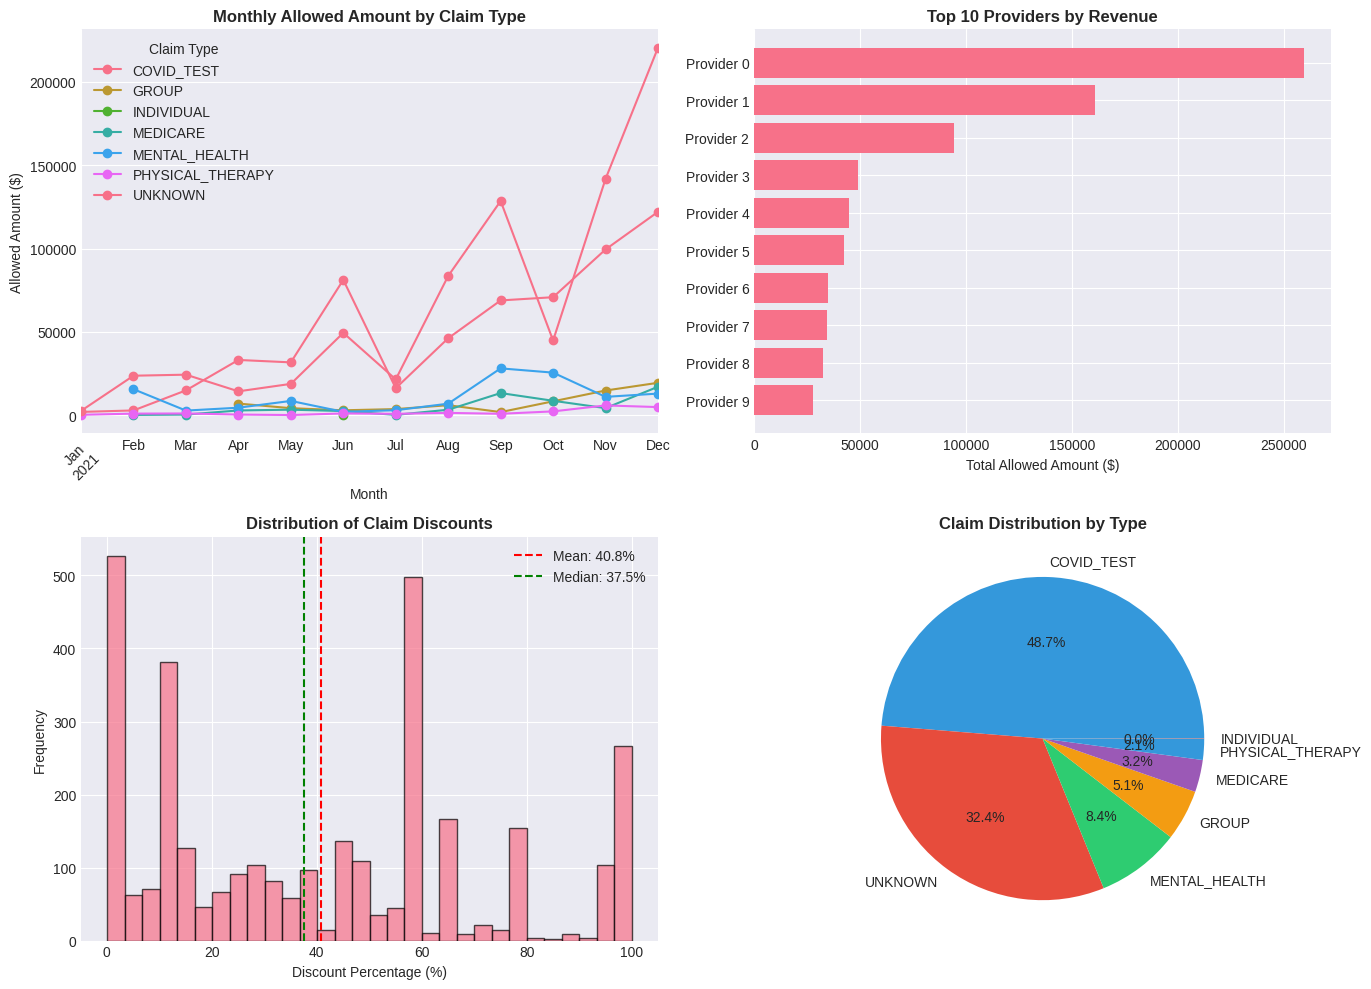


KEY BUSINESS METRICS


,Metric,Value
0,Total Allowed Amount,"$1,629,859"
1,Total Claims Processed,"8,381"
2,Average Claim Value,$194
3,In-Network Rate,98.0%
4,Unique Patients,990
5,Unique Claim Types,7


In [21]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Monthly Trend by Claim Type
ax1 = axes[0, 0]
monthly_pivot = monthly_summary.pivot(index='YEAR_MONTH', columns='CLAIM_TYPE', values='TOTAL_ALLOWED')
monthly_pivot.plot(kind='line', marker='o', ax=ax1)
ax1.set_title('Monthly Allowed Amount by Claim Type', fontsize=12, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Allowed Amount ($)')
ax1.legend(title='Claim Type')
ax1.tick_params(axis='x', rotation=45)

# 2. Top 10 Providers by Allowed Amount (if data available)
ax2 = axes[0, 1]
if not provider_summary.empty:
    top_providers = provider_summary.nlargest(10, 'TOTAL_ALLOWED')
    ax2.barh(range(len(top_providers)), top_providers['TOTAL_ALLOWED'])
    ax2.set_yticks(range(len(top_providers)))
    ax2.set_yticklabels([f"Provider {i}" for i in range(len(top_providers))])
    ax2.set_xlabel('Total Allowed Amount ($)')
    ax2.set_title('Top 10 Providers by Revenue', fontweight='bold')
    ax2.invert_yaxis()
else:
    ax2.text(0.5, 0.5, 'No provider data available', ha='center', va='center')
    ax2.set_title('Provider Data Not Available')

# 3. Discount Rate Distribution
ax3 = axes[1, 0]
discount_data = silver.fact_claim_items[silver.fact_claim_items['DISCOUNT_PCT'] > 0]['DISCOUNT_PCT']
if len(discount_data) > 0:
    ax3.hist(discount_data, bins=30, edgecolor='black', alpha=0.7)
    ax3.axvline(discount_data.mean(), color='red', linestyle='--', label=f'Mean: {discount_data.mean():.1f}%')
    ax3.axvline(discount_data.median(), color='green', linestyle='--', label=f'Median: {discount_data.median():.1f}%')
    ax3.set_xlabel('Discount Percentage (%)')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Distribution of Claim Discounts', fontweight='bold')
    ax3.legend()
else:
    ax3.text(0.5, 0.5, 'No discount data available', ha='center', va='center')

# 4. Claim Type Distribution
ax4 = axes[1, 1]
claim_type_summary = silver.fact_claim_items['CLAIM_TYPE'].value_counts()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'][:len(claim_type_summary)]
ax4.pie(claim_type_summary.values, labels=claim_type_summary.index, autopct='%1.1f%%', colors=colors)
ax4.set_title('Claim Distribution by Type', fontweight='bold')

plt.tight_layout()
plt.show()

# Additional metrics
print("\n" + "="*60)
print("KEY BUSINESS METRICS")
print("="*60)

total_allowed = silver.fact_claim_items['ALLOWED_AMT'].sum()
total_claims = len(silver.fact_claim_items)
avg_claim = total_allowed / total_claims if total_claims > 0 else 0

if 'IN_NETWORK_FLAG' in silver.fact_claim_items.columns:
    in_network_pct = (silver.fact_claim_items['IN_NETWORK_FLAG'].sum() / total_claims * 100) if total_claims > 0 else 0
else:
    in_network_pct = 0

metrics_df = pd.DataFrame({
    'Metric': ['Total Allowed Amount', 'Total Claims Processed', 'Average Claim Value',
               'In-Network Rate', 'Unique Patients', 'Unique Claim Types'],
    'Value': [f'${total_allowed:,.0f}', f'{total_claims:,}', f'${avg_claim:,.0f}',
              f'{in_network_pct:.1f}%',
              silver.fact_claim_items['CLAIMANT_ID'].nunique(),
              len(silver.fact_claim_items['CLAIM_TYPE'].unique())]
})
display(metrics_df)

**7. Data Validation**

In [22]:
print("="*60)
print("DATA VALIDATION & QUALITY CHECKS")
print("="*60)

class DataValidator:
    """Data quality validation suite"""

    @staticmethod
    def check_referential_integrity(fact, dim_provider=None):
        """Check foreign key relationships"""
        issues = []

        # Check provider references if available
        if dim_provider is not None and 'PROVIDER_NPI' in fact.columns:
            invalid_providers = fact[~fact['PROVIDER_NPI'].isin(dim_provider['PROVIDER_NPI'])]['PROVIDER_NPI'].nunique()
            if invalid_providers > 0:
                issues.append(f"⚠️ {invalid_providers} claim rows have invalid provider NPI")

        # Check negative discounts
        negative_discount = (fact['DISCOUNT_AMT'] < 0).sum()
        if negative_discount > 0:
            issues.append(f"⚠️ {negative_discount} rows have negative discounts")

        # Check allowed amount exceeds charged
        allowed_exceeds = (fact['ALLOWED_AMT'] > fact['CHARGE_AMT']).sum()
        if allowed_exceeds > 0:
            issues.append(f"⚠️ {allowed_exceeds} rows where allowed amount > charged amount")

        return issues

    @staticmethod
    def check_completeness(df, required_cols):
        """Check for missing values in critical columns"""
        missing = {}
        for col in required_cols:
            if col in df.columns:
                null_pct = df[col].isnull().sum() / len(df) * 100
                if null_pct > 0:
                    missing[col] = f"{null_pct:.1f}%"
        return missing

    @staticmethod
    def check_uniqueness(df, key_col):
        """Verify primary key uniqueness"""
        if key_col in df.columns:
            duplicate_count = df.duplicated(subset=[key_col]).sum()
            return duplicate_count == 0, duplicate_count
        return False, 0

# Run validations
validator = DataValidator()

# Check fact table integrity
integrity_issues = validator.check_referential_integrity(
    silver.fact_claim_items,
    silver.dim_provider if hasattr(silver, 'dim_provider') else None
)

# Check completeness
required_cols = ['CLAIM_ITEM_ID', 'CLAIMANT_ID', 'CHARGE_AMT', 'ALLOWED_AMT']
missing_values = validator.check_completeness(silver.fact_claim_items, required_cols)

# Check uniqueness
is_unique, dup_count = validator.check_uniqueness(silver.fact_claim_items, 'CLAIM_ITEM_ID')

print(f"\nReferential Integrity:")
for issue in integrity_issues:
    print(f"   {issue}")

print(f"\nCompleteness Check:")
for col, pct in missing_values.items():
    print(f"   {col}: {pct} missing")

print(f"\nPrimary Key Uniqueness:")
print(f"   Claim Item ID unique: {'✅' if is_unique else '❌'} (duplicates: {dup_count})")

# Create quality report
quality_report_df = pd.DataFrame({
    'Check': ['Referential Integrity', 'Data Completeness', 'Primary Key Uniqueness'],
    'Status': ['⚠️ Issues found' if integrity_issues else '✅ Passed',
               '⚠️ Missing values' if missing_values else '✅ Passed',
               '✅ Unique' if is_unique else f'❌ {dup_count} duplicates'],
    'Details': [str(integrity_issues) if integrity_issues else 'All foreign keys valid',
                str(missing_values) if missing_values else 'All critical fields complete',
                f'No duplicates found' if is_unique else f'Found {dup_count} duplicate claim items']
})
display(quality_report_df)

DATA VALIDATION & QUALITY CHECKS

Referential Integrity:

Completeness Check:

Primary Key Uniqueness:
   Claim Item ID unique: ✅ (duplicates: 0)


,Check,Status,Details
0,Referential Integrity,✅ Passed,All foreign keys valid
1,Data Completeness,✅ Passed,All critical fields complete
2,Primary Key Uniqueness,✅ Unique,No duplicates found


**8. Pipeline Summary**

In [23]:
print("="*60)
print("PIPELINE EXECUTION SUMMARY")
print("="*60)

# Display summary stats
total_allowed = silver.fact_claim_items['ALLOWED_AMT'].sum()
total_claims = len(silver.fact_claim_items)
avg_claim = total_allowed / total_claims if total_claims > 0 else 0

print(f"""
📊 Raw Data: {len(df_raw)} rows, {len(df_raw.columns)} columns
🟡 Bronze Layer: {len(bronze)} rows, {len(bronze.columns)} columns
⚪ Silver Layer:
   - Fact Table: {len(silver.fact_claim_items)} rows
   - Provider Dim: {len(silver.dim_provider) if hasattr(silver, 'dim_provider') else 0} rows
   - Diagnosis Bridge: {len(silver.diag_long) if hasattr(silver, 'diag_long') else 0} rows
🟡 Gold Layer:
   - Monthly Summary: {len(monthly_summary)} rows
   - Provider Summary: {len(provider_summary)} rows

🎯 Key Insights:
   - Total Claims Value: ${total_allowed:,.0f}
   - Average Claim: ${avg_claim:,.0f}
   - Unique Patients: {silver.fact_claim_items['CLAIMANT_ID'].nunique():,}
   - Claim Types: {', '.join(silver.fact_claim_items['CLAIM_TYPE'].unique())}
""")

print("\n✅ Pipeline execution completed successfully!")

PIPELINE EXECUTION SUMMARY

📊 Raw Data: 8381 rows, 20 columns
🟡 Bronze Layer: 8381 rows, 25 columns
⚪ Silver Layer: 
   - Fact Table: 8381 rows
   - Provider Dim: 412 rows
   - Diagnosis Bridge: 10988 rows
🟡 Gold Layer:
   - Monthly Summary: 68 rows
   - Provider Summary: 337 rows

🎯 Key Insights:
   - Total Claims Value: $1,629,859
   - Average Claim: $194
   - Unique Patients: 990
   - Claim Types: COVID_TEST, UNKNOWN, PHYSICAL_THERAPY, MENTAL_HEALTH, MEDICARE, GROUP, INDIVIDUAL


✅ Pipeline execution completed successfully!
